# core

> User facing API for solvemail

In [ ]:
#| default_exp core

## Imports

In [ ]:
#| export
from bs4 import BeautifulSoup
from email.utils import parsedate_to_datetime
from fastcore.all import *
from fastgws import GMail
from fastgws.auth import *
from solvemail.email import *

import asyncio,html,httpx,mistletoe,sys

In [ ]:
from fastcore.test import *
from IPython.display import IFrame
from PIL import Image

Gmail's API is a single **REST API** (request/response over HTTPS), organized around a few core resource types:

- **Messages** — individual emails. Each has headers (from, to, subject, date), a body (plain text and/or HTML), labels, and optional attachments.
- **Threads** — conversations. A thread groups related messages (an email and its replies) under one id.
- **Drafts** — unsent messages. A draft wraps a message you can update and later send.
- **Labels** — Gmail's version of folders/tags (`INBOX`, `UNREAD`, `STARRED`, plus your own custom labels). Messages and threads can have many labels at once.

Gmail uses **OAuth 2.0**: the user grants your app permission to act on their behalf, and you receive short-lived access tokens (auto-refreshed) rather than a single static secret. The permissions you request are controlled by **scopes** — e.g. `gmail.readonly` to only read, or `https://mail.google.com/` for full access (needed to permanently delete).

To get started you need an OAuth client secret (`credentials.json`) from a Google Cloud project:

1. Go to the [Google Cloud Console](https://console.cloud.google.com) and create a project (or pick an existing one).
2. Under **APIs & Services → Library**, find the **Gmail API** and enable it.
3. Under **APIs & Services → OAuth consent screen**, configure the consent screen (set the app name, your email, and add your Google account as a test user while in "Testing" mode).
4. Under **APIs & Services → Credentials**, click **Create Credentials → OAuth client ID**, choose **Desktop app** (or Web app with a redirect URI), and create it.
5. Download the JSON — this is your `credentials.json`. Keep it secret; it identifies your app to Google.
6. `solvemail` relies on `fastgws`, which expects this `credentials.json` to be placed your `~/.config/fastgws` folder.

On first run, the OAuth flow opens a browser asking the user to authorize the requested scopes, then caches the resulting token so subsequent runs don't re-prompt.

In [ ]:
#| export
class Gmail:
    def __init__(self, creds, user_id='me'):
        self.client = GMail(creds=creds)
        self.user_id = user_id

    async def profile(self):
        "Profile resource with `email` attribute"
        d = await self.client.users.get_profile(user_id=self.user_id)
        return AttrDict(d, email=d.emailAddress)

In [ ]:
creds = await oauth_creds(scopes=['https://mail.google.com/'])
gmail = Gmail(creds)
profile = await gmail.profile()
me = profile.email
me

'nc@answer.ai'

### Emails

An **email** is a single message. Gmail returns it as a `payload` — a nested tree of MIME parts. A simple email has one part; a typical one is `multipart/alternative` (a `text/plain` and a `text/html` version of the same content); one with files is `multipart/mixed` (the body parts plus attachments).

Fetching is lazy: an `Email` starts as just an id, and is filled in only as needed. How much you get back depends on the `fmt` you ask for — `metadata` brings the headers and snippet (enough for a listing), while `full` brings the entire payload including the body parts. So accessing a header lazily fetches at `metadata`, but the first time you read a body part we upgrade to `full`. (`minimal` gives just ids and labels; `raw` gives the original RFC 2822 bytes.)

`Email` provides helpers for the common parts:

- **`text`** — the raw `text/plain` body, as the sender wrote it.
- **`html(clean=True)`** — the `text/html` body. With `clean=True` we strip Gmail's signature blocks and quoted reply chains, so you get just the new content. Falls back to the text part wrapped in `<pre>` if there's no HTML.
- **`body(clean=True)`** — the cleaned HTML flattened back to readable plain text (`<br>` and block tags become newlines). This is usually what you want for reading or feeding to an LLM.

In [ ]:
#| export
def _flat_hdrs(d):
    if 'payload' not in d: raise ValueError("no headers: use format 'metadata' or 'full'")
    keep = {'date','from','to','subject','message-id','references',
            'reply-to','list-unsubscribe','list-unsubscribe-post'}
    hdrs = {x['name'].lower(): x['value'] for x in d.payload.headers if x['name'].lower() in keep}
    if 'from' in hdrs: hdrs['frm'] = hdrs.pop('from')
    if 'subject' in hdrs: hdrs['subj'] = hdrs.pop('subject')
    if 'message-id' in hdrs: hdrs['rfcid'] = hdrs.pop('message-id')
    d.update(hdrs)
    return d

def _has_att(e): return e.payload.get('mimeType')=='multipart/mixed'

class Email(AttrDict):
    def __init__(self, gmail, d):
        super().__init__(d)
        self.gmail = gmail

    def __repr__(self):
        if 'payload' not in self: return f'Email({self.id})'
        lbls = ','.join(self.get('labelIds') or [])
        att = '📎' if _has_att(self) else ''
        snip = html.unescape(self.get('snippet') or '')
        return f'Email({self.id}: [{lbls}] {att}{self.get("frm", "")} | {self.get("subj", "")}\n{snip})'

    async def refresh(self, fmt='metadata'):
        d = await self.gmail.client.users.messages.get(user_id='me', id=self.id, format=fmt)
        self.update(_flat_hdrs(d))
        return self

    @classmethod
    async def fetch(cls, gmail, id): return await cls(gmail, dict(id=id)).refresh('metadata')

An **email** is a single message. Gmail returns it as a `payload` — a nested tree of MIME parts. A simple email has one part; a typical one is `multipart/alternative` (a `text/plain` and a `text/html` version of the same content); one with files is `multipart/mixed` (the body parts plus attachments).

Fetching is lazy: an `Email` starts as just an id, and the full payload is only fetched from Gmail the first time you access a part that needs it.

`Email` provides helpers for the common parts:

- **`text`** — the raw `text/plain` body, as the sender wrote it.
- **`html(clean=True)`** — the `text/html` body. With `clean=True` we strip Gmail's signature blocks and quoted reply chains, so you get just the new content. Falls back to the text part wrapped in `<pre>` if there's no HTML.
- **`body(clean=True)`** — the cleaned HTML flattened back to readable plain text (`<br>` and block tags become newlines). This is usually what you want for reading or feeding to an LLM.


In [ ]:
#| export
@patch
@delegates(mk_email)
async def send(self:Gmail, thread_id=None, **kwargs):
    sys.audit('solvemail.Gmail.send', kwargs.get('to'), kwargs.get('body'))
    msg = dict(raw=raw_email(mk_email(**kwargs)))
    if thread_id: msg['thread_id'] = thread_id
    return Email(self, await self.client.users.messages.send(user_id=self.user_id, **msg))

In [ ]:
em = await gmail.send(to=me, subj='solvemail html test',
                      body='Hello from **solvemail**!',
                      html='<p>Hello from <b>solvemail</b>!</p>',
                      att=['otter.png'])
em

```python
Email(19fceb70a6b02780)
```

In [ ]:
#| export
@patch(as_prop=True)
async def text(self:Email):
    if 'payload' not in self or 'parts' not in self.payload: await self.refresh('full')
    return txt_part(self.payload)

In [ ]:
print(await em.text)

Hello from **solvemail**!


In [ ]:
#| export
def _clean_html(h):
    "Strip Gmail signatures and reply quotes from html `h`"
    soup = BeautifulSoup(h, 'html.parser')
    for sig in soup.select('.gmail_signature, .gmail_signature_prefix'): sig.decompose()
    for q in soup.select('.gmail_quote'):
        prev = q.find_previous_sibling()
        if prev and prev.get_text(strip=True): q.decompose()
    return str(soup)

@patch
async def html(self:Email, clean=True):
    if 'payload' not in self or 'parts' not in self.payload: await self.refresh('full')
    h = html_part(self.payload)
    return _clean_html(h) if h and clean else h

In [ ]:
IFrame(src='about:blank', width='100%', height=50,
       extras=[f'srcdoc="{html.escape(await em.html())}"'])

In [ ]:
#| export
@patch
async def body(self:Email, clean=True):
    soup = BeautifulSoup(await self.html(clean), 'html.parser')
    for br in soup.find_all('br'): br.replace_with('\n')
    for tag in soup.find_all(['p','div']): tag.append('\n')
    return re.sub(r'\n{3,}', '\n\n', soup.get_text().strip())

In [ ]:
print(await em.body())

Hello from solvemail!


You can search uses Gmail's own query syntax like `from:foo@bar.com`, `subject:invoice`, `has:attachment`, `is:unread`, or `after:2026/01/01`. `search` returns `Email`s (refreshed to `metadata`, so you get senders, subjects, and snippets).

In [ ]:
#| export
def _email_row(e, att=None):
    att = _has_att(e) if att is None else att
    return f'| {e.id} | {e.frm or ""} | {e.get("subj") or ""} | {"📎" if att else ""} | {e.get("date") or ""} |'

_email_hdr = '| id | from | subj | 📎 | date |\n|-|-|-|-|-|\n'
class Emails(L):
    def __init__(self, d, *rest, gmail=None, **kwargs):
        super().__init__(d, *rest, **kwargs)
        self.gmail = gmail

    def _repr_markdown_(self): return _email_hdr + '\n'.join(self.map(_email_row))

    async def refresh(self, fmt='metadata'):
        await parallel_async(Email.refresh, self, fmt)
        return self

@patch
async def _search(self:Gmail, rsrc, key, cls, coll, q=None, max_results=10, **kwargs):
    r = await getattr(self.client.users, rsrc).list(user_id=self.user_id, q=q, max_results=max_results, **kwargs)
    os = L(r.get(key) or []).map(lambda o: cls(self, o))
    return await coll(os, gmail=self).refresh()

@patch
async def search_emails(self:Gmail, q=None, max_results=20, **kwargs):
    return await self._search('messages', 'messages', Email, Emails, q, max_results, **kwargs)



In [ ]:
ems = await gmail.search_emails('has:attachment', max_results=1)
ems

| id | from | subj | 📎 | date |
|-|-|-|-|-|
| 19fceb70a6b02780 | Nathan Cooper <nc@answer.ai> | solvemail html test | 📎 | Tue, 4 Aug 2026 14:38:50 -0700 |

#### Attachments

Emails can carry file attachments, and they show up as extra parts in the payload. `attachments` pulls those out for you as `EmailAttachment` objects, so you get attribute access to things like `filename`, `mimeType`, and `size`. Each one is lazy — the actual bytes aren't downloaded until you call `fetch`, and you can pass `save=` a directory or filename to write it straight to disk.

In [ ]:
#| export
def hsize(n):
    "Human-readable byte size"
    for u in ' KMGT':
        if n < 1024: return f'{n:.0f}{u.strip()}B' if u==' ' else f'{n:.1f}{u}B'
        n /= 1024
    return f'{n:.1f}PB'

class EmailAttachment(AttrDict):
    def __init__(self, gmail, mid, d):
        super().__init__(d)
        self.gmail = gmail
        self.mid = mid

    def __repr__(self): return f'EmailAttachment({self.filename!r}, {self.mimeType}, {hsize(self.body.size)})'

    async def fetch(self, save=None):
        r = await self.gmail.client.users.messages.attachments.get( user_id='me', message_id=self.mid,
                                                                    id=self.body.attachmentId)
        data = b64d(r.data)
        if save:
            p = Path(save)
            if p.is_dir(): p = p/self.filename
            p.write_bytes(data)
        return data

@patch(as_prop=True)
async def attachments(self:Email):
    if 'parts' not in self.payload: await self.refresh('full')
    return att_parts(self.payload).map(lambda a: EmailAttachment(self.gmail, self.id, a))

In [ ]:
em = ems[0]
att = (await em.attachments)[0]
att

```python
EmailAttachment('otter.png', image/png, 1.5MB)
```

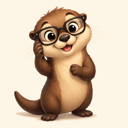

In [ ]:
await att.fetch(save='otter_test.png')
Image.open('otter_test.png').resize((128,128))

In [ ]:
#| export
@patch
async def delete(self:Email):
    sys.audit('solvemail.Email.delete')
    return await self.gmail.client.users.messages.delete(user_id='me', id=self.id)

In [ ]:
await em.delete()

### Drafts

A **draft** is an unsent message. `Draft` subclasses `Email`, so everything you've seen — `text`, `html()`, `body()`, attachments — works on it too; it just carries an extra `draft_id` and reads from the drafts endpoint.

In [ ]:
#| export
class Draft(Email):
    def __init__(self, gmail, d):
        self.draft_id = d.get('id')
        super().__init__(gmail, d.get('message') or {})

    def __repr__(self): return f'Draft({self.draft_id}: ' + super().__repr__()[6:]

    async def refresh(self, fmt='metadata'):
        d = await self.gmail.client.users.drafts.get(user_id='me', id=self.draft_id, format=fmt)
        self.draft_id = d['id']
        self.update(_flat_hdrs(d.message))
        return self

    @classmethod
    async def fetch(cls, gmail, id): return await cls(gmail, dict(id=id)).refresh('metadata')

@patch
@delegates(mk_email)
async def create_draft(self:Gmail, thread_id=None, **kwargs):
    msg = dict(raw=raw_email(mk_email(**kwargs)))
    if thread_id: msg['thread_id'] = thread_id
    d = await self.client.users.drafts.create(user_id=self.user_id, message=msg)
    return await Draft(self, d).refresh('metadata')

In [ ]:
dr = await gmail.create_draft(to='nc@answer.ai', subj='draft test', body='This is a draft!')
dr

```python
Draft(r2284516532190514582: 19fceb7242aca6fe: [DRAFT] Nathan Cooper <nc@answer.ai> | draft test
This is a draft!)
```

Drafts can be updated before sent

In [ ]:
#| export
@patch
@delegates(mk_email)
async def update_draft(self:Draft, thread_id=None, **kwargs):
    defaults = {k: self[k] for k in ('to','subj','cc') if self.get(k)}
    msg = dict(raw=raw_email(mk_email(**{**defaults, **kwargs})))
    if thread_id or self.get('threadId'): msg['thread_id'] = thread_id or self.threadId
    d = await self.gmail.client.users.drafts.update(user_id='me', id=self.draft_id, message=msg)
    self.draft_id = d['id']
    return await self.refresh('metadata')

In [ ]:
await dr.update_draft(body='after update!')

```python
Draft(r2284516532190514582: 19fceb729c150cfb: [DRAFT] Nathan Cooper <nc@answer.ai> | draft test
after update!)
```

In [ ]:
#| export
def _draft_row(d): return f'| {d.draft_id} | {d.get("frm") or ""} | {d.get("subj") or ""} | {d.get("date") or ""} |'

_draft_hdr = '| draft_id | from | subj | date |\n|-|-|-|-|\n'
class Drafts(L):
    def __init__(self, d, *rest, gmail=None, **kwargs):
        super().__init__(d, *rest, **kwargs)
        self.gmail = gmail

    def _repr_markdown_(self): return _draft_hdr + '\n'.join(self.map(_draft_row))

    async def refresh(self, fmt='metadata'):
        await parallel_async(Draft.refresh, self, fmt)
        return self

@patch
async def search_drafts(self:Gmail, q=None, max_results=10, **kwargs):
    return await self._search('drafts', 'drafts', Draft, Drafts, q, max_results, **kwargs)

In [ ]:
drs = await gmail.search_drafts(max_results=1)
drs

| draft_id | from | subj | date |
|-|-|-|-|
| r2284516532190514582 | Nathan Cooper <nc@answer.ai> | draft test | Tue, 4 Aug 2026 16:38:57 -0500 |

In [ ]:
#| export
@patch
async def send(self:Draft):
    sys.audit('solvemail.Draft.send')
    return Email(self.gmail, await self.gmail.client.users.drafts.send(user_id='me', id=self.draft_id))

In [ ]:
em = await dr.send()
em

```python
Email(19fceb72f32fc7e4)
```

A reply contains special headers to enable mail clients to properly associate the email as part of a thread. `_reply_hdrs` is a helper to properly parse these:

- **`to`** — reply to the sender, preferring their `Reply-To` header if they set one, otherwise the `From` address.
- **`subj`** — the original subject prefixed with `Re:` (unless it already starts with one).
- **`In-Reply-To`** — the parent's `Message-ID`, telling clients exactly which email this answers.
- **`References`** — the parent's existing `References` chain plus its `Message-ID`, building the full ancestry of the conversation.

In [ ]:
#| export
def _reply_hdrs(m, me=None):
    "Compute reply headers from parent email `m` (pass `me` for reply-all cc)"
    subj = m.get('subj') or ''
    if not re.match(r'(?i)^re:', subj): subj = f'Re: {subj}'
    refs = ' '.join(filter(None, [m.get('references'), m.get('rfcid')]))
    to = m.get('reply-to') or m.get('frm')
    cc = None
    if me:
        cc = {a.strip() for a in f"{m.get('to','')},{m.get('cc','')}".split(',')
              if a.strip() and a.strip().lower() != me.lower()} - {to}
        cc = ','.join(cc) or None
    return dict(to=to, subj=subj, in_reply_to=m.get('rfcid'), refs=refs or None, cc=cc)

In [ ]:
await em.refresh('metadata')
h = _reply_hdrs(em)
test_eq(h['to'], em.frm)
test_eq(h['subj'], 'Re: draft test')
test_eq(h['in_reply_to'], em.rfcid)
test_eq(h['refs'], em.rfcid)

`reply` is just `reply_draft` followed by a send — so anything that holds for reply drafts holds for replies too.

In [ ]:
#| export
async def _reply_quote(e):
    "Build gmail_quote attribution + blockquote for replied-to email `e`"
    h = await e.html(clean=False) or f"<pre>{await e.text}</pre>"
    when = parsedate_to_datetime(e.get('date')).strftime('%a, %b %-d, %Y at %-I:%M %p')
    attrib = f"On {when} {html.escape(e.get('frm'))} wrote:"
    return (f'<div class="gmail_quote">{attrib}<br>'
            f'<blockquote class="gmail_quote" style="margin:0 0 0 .8ex;'
            f'border-left:1px solid #ccc;padding-left:1ex">{h}</blockquote></div>')

@patch
@delegates(mk_email, but=['to','subj','body','html','headers','cc'])
async def reply_draft(self:Email, body=None, html=None, reply_all=False, **kwargs):
    if 'payload' not in self: await self.refresh('metadata')
    me = (await self.gmail.profile()).email if reply_all else None
    rh = _reply_hdrs(self, me)
    hdrs = {k.replace('_','-'):v for k,v in dict(In_Reply_To=rh['in_reply_to'], References=rh['refs']).items() if v}
    new = html or (mistletoe.markdown(body) if body else '')
    html = new + await _reply_quote(self)
    msg = dict(raw=raw_email(mk_email(to=rh['to'], subj=rh['subj'], cc=rh['cc'],
                                      body=body or '', html=html, headers=hdrs, **kwargs)),
               thread_id=self.threadId)
    d = await self.gmail.client.users.drafts.create(user_id='me', message=msg)
    return await Draft(self.gmail, d).refresh('metadata')

@patch
@delegates(mk_email, but=['to','subj','headers'])
async def reply(self:Email, **kwargs): return await (await self.reply_draft(**kwargs)).send()

In [ ]:
em = await em.reply(body='replying from solvemail v2!')
await em.refresh()

```python
Email(19fceb739531740b: [UNREAD,SENT,INBOX] Nathan Cooper <nc@answer.ai> | Re: draft test
replying from solvemail v2! On Tue, Aug 4, 2026 at 4:38 PM Nathan Cooper <nc@answer.ai> wrote: after update!)
```

### Threads

A **thread** is a conversation — an email plus all its replies, grouped under one id. `Thread` wraps the list of messages as `Email` objects, so once you've fetched one you can index into it and use everything you already know about emails. Like emails, threads fetch lazily and respect the same `fmt` levels.

In [ ]:
#| export
class Thread(AttrDict):
    def __init__(self, gmail, d):
        super().__init__(d)
        self.gmail = gmail
        self._set_emails()

    def _set_emails(self):
        self.emails = Emails(L(self.get('messages') or []).map(lambda m: Email(self.gmail, _flat_hdrs(m))), gmail=self.gmail)

    def __repr__(self):
        if not self.emails: return f'Thread({self.id})'
        m = self.emails[-1]
        att = '📎' if any(e.payload.get('mimeType')=='multipart/mixed' for e in self.emails) else ''
        return f'Thread({self.id}: {len(self.emails)} emails, [{",".join(m.labelIds or [])}] {att}{m.frm} -> {m.to} | {m.subj})'
    def _repr_markdown_(self): return self.emails._repr_markdown_()

    async def refresh(self, fmt='metadata'):
        d = await self.gmail.client.users.threads.get(user_id='me', id=self.id, format=fmt)
        self.update(d)
        self._set_emails()
        return self

    @classmethod
    async def fetch(cls, gmail, id): return await cls(gmail, dict(id=id)).refresh('metadata')

    @property
    def labelIds(self): return list({l for e in self.emails for l in (e.labelIds or [])})

    @property
    async def attachments(self):
        atts = await asyncio.gather(*self.emails.map(lambda e: e.attachments))
        return L(a for es in atts for a in es)

In [ ]:
th = await Thread.fetch(gmail, em.threadId)
th

| id | from | subj | 📎 | date |
|-|-|-|-|-|
| 19fceb72f32fc7e4 | Nathan Cooper <nc@answer.ai> | draft test |  | Tue, 4 Aug 2026 16:38:59 -0500 |
| 19fceb739531740b | Nathan Cooper <nc@answer.ai> | Re: draft test |  | Tue, 4 Aug 2026 16:39:01 -0500 |

In [ ]:
#| export
@patch(as_prop=True)
def last(self:Thread): return self.emails[-1]

@patch
@delegates(mk_email, but=['to','subj','headers'])
async def reply_draft(self:Thread, **kwargs):
    dr = await self.last.reply_draft(**kwargs)
    await self.refresh('metadata')
    return dr

@patch
@delegates(mk_email, but=['to','subj','headers'])
async def reply(self:Thread, **kwargs):
    em = await self.last.reply(**kwargs)
    await self.refresh('metadata')
    return em

In [ ]:
await th.reply(body='Replying to the thread!')
th

| id | from | subj | 📎 | date |
|-|-|-|-|-|
| 19fceb72f32fc7e4 | Nathan Cooper <nc@answer.ai> | draft test |  | Tue, 4 Aug 2026 16:38:59 -0500 |
| 19fceb739531740b | Nathan Cooper <nc@answer.ai> | Re: draft test |  | Tue, 4 Aug 2026 16:39:01 -0500 |
| 19fceb740dd9b3b4 | Nathan Cooper <nc@answer.ai> | Re: draft test |  | Tue, 4 Aug 2026 23:39:03 +0200 |

In [ ]:
#| export
def _thread_row(t): return _email_row(t.emails[-1], any(_has_att(e) for e in t.emails)) + f' {len(t.emails)} |'

_thread_hdr = _email_hdr.replace('|\n|-', '| emails |\n|-').replace('-|\n', '-|-|\n')
class Threads(L):
    def __init__(self, d, *rest, gmail=None, **kwargs):
        super().__init__(d, *rest, **kwargs)
        self.gmail = gmail

    def _repr_markdown_(self): return _thread_hdr + '\n'.join(self.map(_thread_row))

    async def refresh(self, fmt='metadata'):
        await parallel_async(Thread.refresh, self, fmt)
        return self

@patch
async def search_threads(self:Gmail, q=None, max_results=10, **kwargs):
    return await self._search('threads', 'threads', Thread, Threads, q, max_results, **kwargs)

In [ ]:
await gmail.search_threads(max_results=1)

| id | from | subj | 📎 | date | emails |
|-|-|-|-|-|-|
| 19fceb740dd9b3b4 | Nathan Cooper <nc@answer.ai> | Re: draft test |  | Tue, 4 Aug 2026 23:39:03 +0200 | 3 |

### Forwarding

Forwarding isn't a real operation at the email level — a forward is just a new message with the original content pasted into its body and the original subject prefixed with `Fwd:`. Unlike a reply, the original attachments don't come along on their own, so we re-download each one and attach it to the new message. We forward the whole conversation, not just one message: `Email.forward` fetches the thread and includes every message up to and including itself (sorted by `internalDate`), and `Thread.forward` just forwards from its last message. The forwarded bodies are kept uncleaned so signatures and earlier quotes stay intact.

In [ ]:
#| export
async def _fwd_one(e):
    "Build (html_block, att_tuples) for one forwarded message `e`"
    hdr = (f"\n\n---------- Forwarded message ----------\n\n"
           f"**From:** {e.get('frm')}  \n**Date:** {e.get('date')}  \n"
           f"**Subject:** {e.get('subj')}  \n**To:** {e.get('to')}  \n")
    body = await e.html(clean=False) or f"<pre>{await e.text}</pre>"
    atts = await e.attachments
    tups = await asyncio.gather(*atts.map(lambda a: a.fetch()))
    return mistletoe.markdown(hdr) + body, [(a.filename, d, a.mimeType) for a,d in zip(atts,tups)]

@patch
@delegates(mk_email, but=['subj','html','att','headers'])
async def forward(self:Email, to, subj=None, body=None, att=None, **kwargs):
    if 'internalDate' not in self: await self.refresh('full')
    th = await Thread.fetch(self.gmail, self.threadId)
    ems = th.emails.sorted(lambda e: int(e.internalDate)).filter(lambda e: int(e.internalDate) <= int(self.internalDate))
    parts = await asyncio.gather(*ems.map(_fwd_one))
    html = (mistletoe.markdown(body) if body else '') + ''.join(h for h,_ in parts)
    att = list(att or []) + [a for _,fa in parts for a in fa]
    return await self.gmail.send(to=to, subj=subj or f"Fwd: {self.get('subj')}", body=body or '', html=html, att=att, **kwargs)

@patch
@delegates(Email.forward)
async def forward(self:Thread, **kwargs): return await self.last.forward(**kwargs)

In [ ]:
await th.reply(body='Cute otter!', att=['otter.png'])
fwd = await th.forward(to=me, body='FYI, see below')
await fwd.refresh('full')

h = await fwd.html(clean=False)
test_eq(h.count('Forwarded message'), 4) # both messages included
fwd_atts = await fwd.attachments
test_eq(L(fwd_atts).attrgot('filename'), ['otter.png']) # original file re-attached

In [ ]:
await fwd.delete()

### Labels

Labels are Gmail's tags. System labels (`INBOX`, `STARRED`) use their name as their id, but custom labels have an id like `Label_42` that differs from their name. So anywhere you pass a label, we resolve names to ids for you — `modify(add='Receipts')` works by name. The label list is cached after the first fetch and cleared on any create/rename/delete.

In [ ]:
#| export
_sys_lbls = set('INBOX SPAM TRASH UNREAD STARRED IMPORTANT SENT DRAFT CHAT '
                'CATEGORY_FORUMS CATEGORY_UPDATES CATEGORY_PERSONAL '
                'CATEGORY_PROMOTIONS CATEGORY_SOCIAL'.split())
def _norm_lbl(l): return l.upper() if isinstance(l,str) and l.upper() in _sys_lbls else l

class Label(AttrDict):
    def __init__(self, gmail, d):
        super().__init__(d)
        self.gmail = gmail
    def __repr__(self): return f'Label({self.id}:{self.name})'
    @property
    def is_sys(self): return self.get('type')=='system' or self.id in _sys_lbls

    async def refresh(self):
        self.update(await self.gmail.client.users.labels.get(user_id='me', id=self.id))
        self.gmail._lbls = None
        return self
    async def delete(self):
        sys.audit('solvemail.Label.delete')
        await self.gmail.client.users.labels.delete(user_id='me', id=self.id)
        self.gmail._lbls = None
    async def patch(self, **kwargs):
        self.update(await self.gmail.client.users.labels.patch(user_id='me', id=self.id, **kwargs))
        self.gmail._lbls = None
        return self
    async def rename(self, name): return await self.patch(name=name)

@patch
async def labels(self:Gmail, refresh=False):
    if refresh or self._lbls is None:
        d = await self.client.users.labels.list(user_id=self.user_id)
        self._lbls = L(d.get('labels') or []).map(lambda o: Label(self, o))
    return self._lbls

@patch
async def label(self:Gmail, lbl, refresh=False):
    lbl = _norm_lbl(lbl)
    if isinstance(lbl, Label): return lbl
    lbls = await self.labels(refresh=refresh)
    d = {**{o.name:o for o in lbls}, **{o.id:o for o in lbls}}
    if lbl in d: return d[lbl]
    raise KeyError(f'Unknown label: {lbl}')

@patch
async def lbl_ids(self:Gmail, lbls):
    if lbls is None: return []
    async def _one(l):
        l = _norm_lbl(l)
        if isinstance(l, Label): return l.id
        if isinstance(l, str) and l in _sys_lbls: return l
        try: return (await self.label(l)).id
        except KeyError: return l
    ls = L(lbls) if is_listy(lbls) else L([lbls])
    return L(await asyncio.gather(*ls.map(_one))).filter().unique().items

@patch
async def create_label(self:Gmail, name):
    d = await self.client.users.labels.create(user_id=self.user_id, name=name)
    self._lbls = None
    return Label(self, d)

In [ ]:
lbl = await gmail.create_label('Receipt')
test_eq(lbl.name, 'Receipt')
assert not lbl.is_sys

In [ ]:
#| export
@patch
async def modify(self:Email, add=None, rm=None):
    return self.update(await self.gmail.client.users.messages.modify(
        user_id='me', id=self.id,
        add_label_ids=await self.gmail.lbl_ids(add),
        remove_label_ids=await self.gmail.lbl_ids(rm)))

@patch
async def modify(self:Thread, add=None, rm=None):
    await self.gmail.client.users.threads.modify(
        user_id='me', id=self.id,
        add_label_ids=await self.gmail.lbl_ids(add),
        remove_label_ids=await self.gmail.lbl_ids(rm))
    return await self.refresh()

In [ ]:
await em.modify(add=lbl.name)
await em.refresh('metadata')
assert lbl.id in em.labelIds
assert 'INBOX' in em.labelIds

In [ ]:
#| export
@patch
async def find_labels(self:Gmail, term, regex=False):
    lbls = await self.labels()
    if regex: return lbls.filter(lambda o: re.search(term, o.name))
    return lbls.filter(lambda o: term.lower() in o.name.lower())

In [ ]:
# lookup + normalization
test_eq((await gmail.label('inbox')).id, 'INBOX')          # case-insensitive system
test_eq(await gmail.lbl_ids(['inbox', lbl.name]), ['INBOX', lbl.id])
test_eq((await gmail.find_labels('receipt'))[0].id, lbl.id)

await lbl.rename('Invoice')
test_eq((await gmail.label(lbl.id, refresh=True)).name, 'Invoice')

await em.delete()
await lbl.delete()

In [ ]:
#| export
@patch(as_prop=True)
async def labels(self:Email):
    if 'labelIds' not in self: await self.refresh('metadata')
    return L(await asyncio.gather(*L(self.labelIds).map(self.gmail.label))).attrgot('name')

@patch(as_prop=True)
async def labels(self:Thread):
    return L(await asyncio.gather(*L(self.labelIds).map(self.gmail.label))).attrgot('name')

In [ ]:
#| export
#| hide
@patch
async def mark_read(self:(Email,Thread)):   return await self.modify(rm='UNREAD')
@patch
async def mark_unread(self:(Email,Thread)): return await self.modify(add='UNREAD')
@patch
async def star(self:(Email,Thread)):        return await self.modify(add='STARRED')
@patch
async def unstar(self:(Email,Thread)):      return await self.modify(rm='STARRED')
@patch
async def archive(self:(Email,Thread)):     return await self.modify(rm='INBOX')
@patch
async def inbox(self:(Email,Thread)):       return await self.modify(add='INBOX')

In [ ]:
await th.star()
await th.labels

['STARRED', 'UNREAD', 'SENT', 'INBOX']

Gmail treats trashing and deletions differently. Trashing moves an email or thread to the `TRASH` label, where Gmail keeps it for 30 days before purging it for good. `untrash` reverses that, so it's a safe, recoverable operation (unlike `delete`, which is permanent).

In [ ]:
#| export
@patch
async def trash(self:Email):
    sys.audit('solvemail.Email.trash')
    return self.update(await self.gmail.client.users.messages.trash(user_id='me', id=self.id))
@patch
async def untrash(self:Email): return self.update(await self.gmail.client.users.messages.untrash(user_id='me', id=self.id))

@patch
async def trash(self:Thread):
    sys.audit('solvemail.Thread.trash')
    await self.gmail.client.users.threads.trash(user_id='me', id=self.id)
    return await self.refresh()
@patch
async def untrash(self:Thread):
    await self.gmail.client.users.threads.untrash(user_id='me', id=self.id)
    return await self.refresh()

In [ ]:
await th.trash()
await th.labels

['STARRED', 'UNREAD', 'SENT', 'TRASH']

In [ ]:
await th.untrash()
await th.labels

['STARRED', 'UNREAD', 'SENT']

In [ ]:
#| export
@patch
async def delete(self:Draft):
    sys.audit('solvemail.Draft.delete')
    return await self.gmail.client.users.drafts.delete(user_id='me', id=self.draft_id)

@patch
async def delete(self:Thread):
    sys.audit('solvemail.Thread.delete')
    return await self.gmail.client.users.threads.delete(user_id='me', id=self.id)

In [ ]:
await th.delete()

### Batch Operations

In [ ]:
#| export
@patch
async def batch_modify(self:Gmail, ids, add=None, rm=None):
    "Add/remove `add`/`rm` labels from all messages in `ids`"
    return await self.client.users.messages.batch_modify(
        user_id=self.user_id, ids=listify(ids),
        add_label_ids=await self.lbl_ids(add),
        remove_label_ids=await self.lbl_ids(rm))

@patch
async def batch_delete(self:Gmail, ids):
    sys.audit('solvemail.Gmail.batch_delete', listify(ids))
    return await self.client.users.messages.batch_delete(
        user_id=self.user_id, ids=listify(ids))

@patch
async def modify(self:Emails, add=None, rm=None):
    return await self.gmail.batch_modify(self.attrgot('id'), add, rm)

@patch
async def delete(self:Emails):
    return await self.gmail.batch_delete(self.attrgot('id'))

@patch
async def trash(self:Emails):       return await self.modify(add='TRASH')
@patch
async def untrash(self:Emails):     return await self.modify(rm='TRASH')
@patch
async def mark_read(self:Emails):   return await self.modify(rm='UNREAD')
@patch
async def mark_unread(self:Emails): return await self.modify(add='UNREAD')
@patch
async def star(self:Emails):        return await self.modify(add='STARRED')
@patch
async def unstar(self:Emails):      return await self.modify(rm='STARRED')
@patch
async def archive(self:Emails):     return await self.modify(rm='INBOX')

In [ ]:
sent = await asyncio.gather(*[gmail.send(to=me, subj=f'batch test {i}', body=f'test {i}') for i in range(3)])
ems = await Emails(sent, gmail=gmail).refresh('metadata')

In [ ]:
# batch modify: add a label and mark unread
lbl = await gmail.create_label('BatchTest')
await ems.modify(add=[lbl.name, 'UNREAD'])
await ems.refresh()
test_eq([lbl.id in e.labelIds for e in ems], [True]*3)
test_eq(['UNREAD' in e.labelIds for e in ems], [True]*3)

In [ ]:
# batch convenience: mark read + star
await ems.mark_read()
await ems.star()
await ems.refresh()
test_eq(['UNREAD' in e.labelIds for e in ems], [False]*3)
test_eq(['STARRED' in e.labelIds for e in ems], [True]*3)

In [ ]:
# batch trash + untrash
await ems.trash()
await ems.refresh()
test_eq(['TRASH' in e.labelIds for e in ems], [True]*3)
await ems.untrash()
await ems.refresh()
test_eq(['TRASH' in e.labelIds for e in ems], [False]*3)

In [ ]:
# batch delete (permanent)
ids = ems.attrgot('id')
await ems.delete()
await lbl.delete()

### Unsubscribe

Well-behaved senders include a `List-Unsubscribe` header telling you how to opt out — either a `mailto:` address to email or a URL to POST to (flagged one-click by `List-Unsubscribe-Post`). `unsubscribe` reads that header and does whichever the sender offered, so you don't have to hunt for the link buried in the email.

In [ ]:
sub1 = await gmail.send( to=me, subj='fake newsletter',
                        body='Pretend marketing content',
                        headers={'List-Unsubscribe': f'<mailto:{me}?subject=unsubscribe>'})
sub2 = await gmail.send( to=me, subj='fake newsletter (http)',
                        body='Pretend marketing content',
                        headers={'List-Unsubscribe': '<https://fast-http-bin.pla.sh/post>',
                                 'List-Unsubscribe-Post': 'List-Unsubscribe=One-Click'})

await sub1.refresh('metadata'), await sub2.refresh('metadata')

(Email(19fceb7a2e02d8fe: [UNREAD,SENT,INBOX] Nathan Cooper <nc@answer.ai> | fake newsletter
 Pretend marketing content),
 Email(19fceb7a54996035: [UNREAD,SENT,INBOX] Nathan Cooper <nc@answer.ai> | fake newsletter (http)
 Pretend marketing content))

In [ ]:
#| export
def _parse_unsub(unsub, post=None):
    "Parse a List-Unsubscribe header into an action dict"
    if not unsub: return None
    for url in re.findall(r'<([^>]+)>', unsub):
        if url.startswith('mailto:'):
            addr,_,qs = url[7:].partition('?')
            subj = dict(p.split('=',1) for p in qs.split('&')).get('subject','unsubscribe') if qs else 'unsubscribe'
            return dict(kind='mailto', addr=addr, subj=subj)
        if url.startswith('http'):
            return dict(kind='http', url=url, post=post or 'List-Unsubscribe=One-Click')
    return None

In [ ]:
unsub1_md = _parse_unsub(sub1['list-unsubscribe'])
unsub2_md = _parse_unsub(sub2['list-unsubscribe'],  sub2['list-unsubscribe-post'])
unsub1_md, unsub2_md

({'kind': 'mailto', 'addr': 'nc@answer.ai', 'subj': 'unsubscribe'},
 {'kind': 'http',
  'url': 'https://fast-http-bin.pla.sh/post',
  'post': 'List-Unsubscribe=One-Click'})

In [ ]:
#| export
@patch
async def unsubscribe(self:Email):
    "Unsubscribe via List-Unsubscribe header (mailto or HTTP one-click POST)"
    if 'payload' not in self: await self.refresh('metadata')
    act = _parse_unsub(self.get('list-unsubscribe'), self.get('list-unsubscribe-post'))
    if not act: return None
    if act['kind'] == 'mailto': return await self.gmail.send(to=act['addr'], subj=act['subj'], body='unsubscribe')
    return httpx.post(act['url'], content=act['post'],
                      headers={'Content-Type':'application/x-www-form-urlencoded'})

@patch
async def unsubscribe(self:Thread): return await self.last.unsubscribe()

In [ ]:
unsub1 = await (await sub1.unsubscribe()).refresh('metadata')
unsub2 = (await sub2.unsubscribe()).json()

test_eq(unsub1_md['addr'], unsub1.to)
test_eq(unsub1_md['subj'], unsub1.subj)
test_eq(unsub2_md['url'], unsub2['url'])
test_eq(unsub2['form'], {'List-Unsubscribe': 'One-Click'})

In [ ]:
await sub1.delete()
await sub2.delete()
await unsub1.delete()

In [ ]:
#| hide
import nbdev; nbdev.nbdev_export()